# RACE Attention - Phase 1: Measure the Baseline

**Goal:** measure how the *existing* RACE attention (the PyTorch version the model actually runs) behaves as the input gets longer, in both **speed** and **GPU memory**.

This is the "before" picture. Every later "I made it faster" claim is measured against these numbers.

Swept over sequence length `T`, we record:
- **forward time** (milliseconds)
- **peak GPU memory** (GB), which caps how long a sequence we can handle
- **throughput** (millions of tokens / second)

The outputs saved in this notebook were produced by running all cells top-to-bottom on a single NVIDIA A100-SXM4-40GB.

In [1]:
import torch, math, time, gc
import torch.nn as nn
import torch.nn.functional as F
import itertools

print("torch:", torch.__version__)
assert torch.cuda.is_available(), "No GPU detected -- set the Colab runtime to A100/H100."
p = torch.cuda.get_device_properties(0)
print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB total | compute capability {p.major}.{p.minor}")

torch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-40GB | 42.4 GB total | compute capability 8.0


In [2]:
# RACE's CAUSAL forward, copied faithfully from the repo (misc/race.py -> class BatchedACE).
# This is the path the real model runs. On every call it builds B_pref = [N, T, L, R, d_k]
# in memory via cumsum -- that giant scratch tensor is what eats memory at long sequence
# lengths. We keep it EXACTLY as the authors wrote it so the later speedup is a fair fight.

class BatchedACE(nn.Module):
    def __init__(self, d_k, K, L, M, device="cpu", share_planes=True):
        super().__init__()
        self.d_k, self.K, self.L, self.M = d_k, K, L, M
        self.R = 1 << K
        self.share_planes = share_planes
        if share_planes:
            planes = torch.randn(L, K, d_k, device=device)
            self.register_buffer("planes_T", planes.view(L * K, d_k).T)         # [d_k, L*K]
        else:
            planes = torch.randn(M, L, K, d_k, device=device)
            planes = planes.view(M, L * K, d_k).transpose(1, 2)
            self.register_buffer("planes_T", planes)
        corners = torch.tensor(list(itertools.product([-1., 1.], repeat=K)), device=device)
        self.register_buffer("protos_T", corners.T)                             # [K, R]

    def forward(self, Khf, Vhf, Qhf):
        M, B, T, H, dk = Khf.shape
        scale = math.sqrt(dk)
        if self.share_planes:
            N = M * B * H
            Kh2 = Khf.permute(0, 1, 3, 2, 4).contiguous().view(N, T, dk)
            Qh2 = Qhf.permute(0, 1, 3, 2, 4).contiguous().view(N, T, dk)
            V2  = Vhf.permute(0, 1, 3, 2, 4).contiguous().view(N, T, dk)
            projK = Kh2 @ self.planes_T
            projQ = Qh2 @ self.planes_T
        else:
            BH = B * H
            Kh2 = Khf.permute(0, 1, 3, 2, 4).contiguous().view(M, BH, T, dk)
            Qh2 = Qhf.permute(0, 1, 3, 2, 4).contiguous().view(M, BH, T, dk)
            V2  = Vhf.permute(0, 1, 3, 2, 4).contiguous().view(M, BH, T, dk)
            projK = torch.einsum("mbtd,mds->mbts", Kh2, self.planes_T)
            projQ = torch.einsum("mbtd,mds->mbts", Qh2, self.planes_T)
            projK = projK.contiguous().view(M * BH, T, self.L * self.K)
            projQ = projQ.contiguous().view(M * BH, T, self.L * self.K)
            V2 = V2.view(M * BH, T, dk); N = M * BH
        projK = projK.view(N, T, self.L, self.K)
        projQ = projQ.view(N, T, self.L, self.K)
        probsK = F.softmax(projK.tanh().div(scale) @ self.protos_T, dim=-1)      # [N,T,L,R]
        probsQ = F.softmax(projQ.tanh().div(scale) @ self.protos_T, dim=-1)
        A_pref = probsK.cumsum(dim=1)                                            # [N,T,L,R]
        B_pref = (probsK.unsqueeze(-1) * V2.unsqueeze(2).unsqueeze(3)).cumsum(dim=1)  # [N,T,L,R,d_k]  <-- big
        E_pref = B_pref.div(A_pref.unsqueeze(-1).add(1e-6))
        S = self.L * self.R
        out2 = torch.bmm(probsQ.view(N * T, 1, S), E_pref.contiguous().view(N * T, S, dk)).view(N, T, dk)
        return out2.view(M, B, H, T, dk).permute(0, 1, 3, 2, 4)

print("BatchedACE (causal RACE baseline) defined.")

BatchedACE (causal RACE baseline) defined.


In [3]:
# ---- benchmark config: a small, realistic attention layer ----
cfg = dict(M=1, B=1, H=8, d_k=64, K=4, L=4)      # S = L * 2^K buckets
S = cfg["L"] * (1 << cfg["K"])
N = cfg["M"] * cfg["B"] * cfg["H"]
bpref_kb = N * S * cfg["d_k"] * 4 / 1024
print(f"config {cfg}  ->  N={N} streams, S={S} buckets, head_dim={cfg['d_k']}")
print(f"B_pref scratch table grows ~{bpref_kb:.0f} KB per token  (the memory hog)")
print()

def make_inputs(T):
    g = torch.Generator(device="cuda").manual_seed(0)
    shape = (cfg["M"], cfg["B"], T, cfg["H"], cfg["d_k"])
    K = torch.randn(shape, device="cuda", generator=g)
    V = torch.randn(shape, device="cuda", generator=g)
    Q = torch.randn(shape, device="cuda", generator=g)
    return K, V, Q

def time_forward(ace, K, V, Q, warmup=2, iters=5):
    for _ in range(warmup):
        ace(K, V, Q)
    torch.cuda.synchronize()
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    ts = []
    for _ in range(iters):
        s.record(); ace(K, V, Q); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    ts.sort()
    return ts[len(ts) // 2]

ace = BatchedACE(cfg["d_k"], cfg["K"], cfg["L"], cfg["M"], device="cuda")

Ts = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576]
rows = []
print(f"{'T':>9} | {'fwd ms':>9} | {'peak GB':>8} | {'M tok/s':>8}")
print("-" * 44)
for T in Ts:
    try:
        torch.cuda.empty_cache(); gc.collect()
        torch.cuda.reset_peak_memory_stats()
        K, V, Q = make_inputs(T)
        ms = time_forward(ace, K, V, Q)
        peak = torch.cuda.max_memory_allocated() / 1e9
        mtoks = N * T / (ms / 1e3) / 1e6
        rows.append((T, ms, peak, mtoks))
        print(f"{T:>9} | {ms:9.2f} | {peak:8.2f} | {mtoks:8.2f}")
        del K, V, Q
    except RuntimeError as err:
        if "out of memory" in str(err).lower():
            print(f"{T:>9} |  OUT OF MEMORY  <-- this is the baseline's wall")
            rows.append((T, float("nan"), float("nan"), float("nan")))
            torch.cuda.empty_cache()
            break
        raise

import csv
with open("phase1_baseline.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["T", "fwd_ms", "peak_gb", "Mtok_per_s"]); w.writerows(rows)
print()
print("saved phase1_baseline.csv")

config {'M': 1, 'B': 1, 'H': 8, 'd_k': 64, 'K': 4, 'L': 4}  ->  N=8 streams, S=64 buckets, head_dim=64
B_pref scratch table grows ~128 KB per token  (the memory hog)

        T |    fwd ms |  peak GB |  M tok/s
--------------------------------------------
      512 |      1.06 |     0.15 |     3.88
     1024 |      1.69 |     0.30 |     4.86
     2048 |      3.03 |     0.59 |     5.41
     4096 |      6.59 |     1.17 |     4.98
     8192 |     12.57 |     2.33 |     5.21
    16384 |     24.97 |     4.66 |     5.25
    32768 |     49.96 |     9.30 |     5.25
    65536 |     99.88 |    18.60 |     5.25
   131072 |  OUT OF MEMORY  <-- this is the baseline's wall

saved phase1_baseline.csv


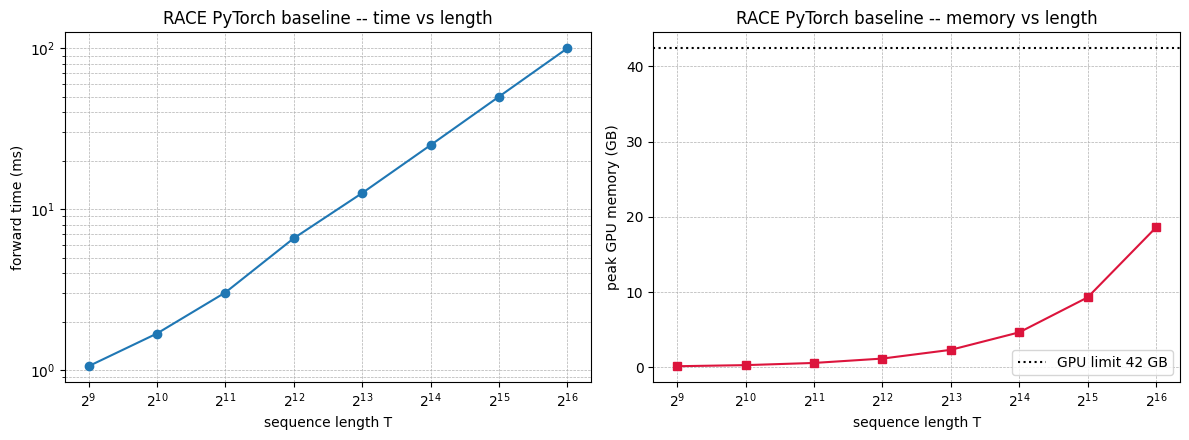

saved phase1_baseline.png


In [4]:
import matplotlib.pyplot as plt

ok  = [r for r in rows if not math.isnan(r[1])]
xs  = [r[0] for r in ok]
ms  = [r[1] for r in ok]
mem = [r[2] for r in ok]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(xs, ms, "o-")
ax[0].set_xscale("log", base=2); ax[0].set_yscale("log")
ax[0].set_xlabel("sequence length T"); ax[0].set_ylabel("forward time (ms)")
ax[0].set_title("RACE PyTorch baseline -- time vs length")
ax[0].grid(True, which="both", ls="--", lw=0.5)

ax[1].plot(xs, mem, "s-", color="crimson")
ax[1].set_xscale("log", base=2)
ax[1].set_xlabel("sequence length T"); ax[1].set_ylabel("peak GPU memory (GB)")
ax[1].set_title("RACE PyTorch baseline -- memory vs length")
ax[1].grid(True, which="both", ls="--", lw=0.5)
total = torch.cuda.get_device_properties(0).total_memory / 1e9
ax[1].axhline(total, color="k", ls=":", label=f"GPU limit {total:.0f} GB")
ax[1].legend()

plt.tight_layout()
plt.savefig("phase1_baseline.png", dpi=150)
plt.show()
print("saved phase1_baseline.png")

## What to look for

- **Memory (right plot) rises in a straight line and slams into the GPU limit.** That OOM point is the baseline's ceiling, the longest sequence it can handle. Pushing that ceiling further right is the goal of the fused kernel.
- **Time (left plot) climbs steeply**, because the model writes and re-reads that giant `B_pref` scratch table every step.

**Next (Phase 2):** rewrite this same math the memory-light way (no `B_pref` table) in plain PyTorch and check it gives the same answers, then (Phase 3) turn it into a fused GPU kernel and overlay its curve on these plots.